<a href="https://colab.research.google.com/github/Shashank-sketchAl/ML-90-Day-Challenge-/blob/main/DAY_13_%E2%80%94_SVM_PRACTICE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_wine

data = load_wine()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget names:")
print(data.target_names)

print("\nClass distribution:")
print(y.value_counts().sort_index())

X shape: (178, 13)
y shape: (178,)

Target names:
['class_0' 'class_1' 'class_2']

Class distribution:
0    59
1    71
2    48
Name: count, dtype: int64


In [3]:
print("Feature name:")
print(data.feature_names)

print("Missing Values:")
print(X.isnull().sum().sum())

print("Dataset statistics:")
print(X.describe())

Feature name:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Missing Values:
0
Dataset statistics:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenol

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training samples: 142
Testing samples: 36

Training class distribution:
0    47
1    57
2    38
Name: count, dtype: int64

Testing class distribution:
0    12
1    14
2    10
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (142, 13)
Testing data shape: (36, 13)


In [6]:
from sklearn.svm import SVC
linear_svm = SVC(kernel='linear',C=1)

linear_svm.fit(X_train_scaled,y_train)
y_pred_linear = linear_svm.predict(X_test_scaled)

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

linear_accuracy = accuracy_score(y_test, y_pred_linear)

linear_precision = precision_score(
    y_test,
    y_pred_linear,
    average='weighted'
)

linear_recall = recall_score(
    y_test,
    y_pred_linear,
    average='weighted'
)

linear_f1 = f1_score(
    y_test,
    y_pred_linear,
    average='weighted'
)

print("Linear SVM Results")
print("-------------------------")
print(f"Accuracy : {linear_accuracy:.4f}")
print(f"Precision: {linear_precision:.4f}")
print(f"Recall   : {linear_recall:.4f}")
print(f"F1 Score : {linear_f1:.4f}")

Linear SVM Results
-------------------------
Accuracy : 0.9444
Precision: 0.9466
Recall   : 0.9444
F1 Score : 0.9443


In [8]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_linear,
    target_names=data.target_names
))

              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



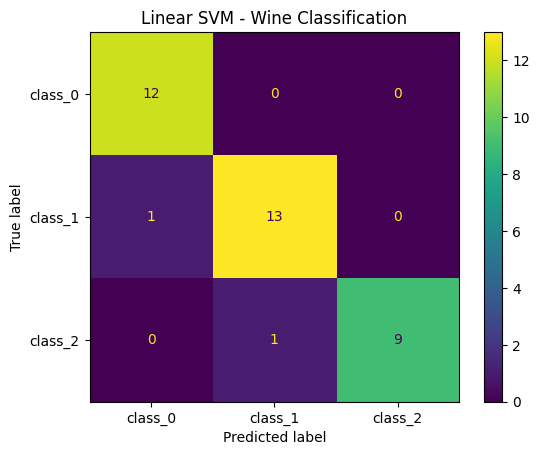

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_linear,
    display_labels=data.target_names
)

plt.title("Linear SVM - Wine Classification")
plt.show()

SVM Multiclass Classification

SVM can be used for multiclass classification.
Scikit-learn handles the multiclass strategy internally.

For multiclass evaluation:
- Use average='weighted' for precision, recall and F1.
- Confusion matrix shows which classes are being confused.

Diagonal of confusion matrix:
Correct predictions

Off-diagonal:
Incorrect predictions

In [10]:
from sklearn.svm import SVC

rbf_svm = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

rbf_svm.fit(X_train_scaled, y_train)

y_pred_rbf = rbf_svm.predict(X_test_scaled)

In [11]:
rbf_accuracy = accuracy_score(y_test, y_pred_rbf)

rbf_precision = precision_score(
    y_test,
    y_pred_rbf,
    average='weighted'
)

rbf_recall = recall_score(
    y_test,
    y_pred_rbf,
    average='weighted'
)

rbf_f1 = f1_score(
    y_test,
    y_pred_rbf,
    average='weighted'
)

print("RBF SVM Results")
print("-------------------------")
print(f"Accuracy : {rbf_accuracy:.4f}")
print(f"Precision: {rbf_precision:.4f}")
print(f"Recall   : {rbf_recall:.4f}")
print(f"F1 Score : {rbf_f1:.4f}")

RBF SVM Results
-------------------------
Accuracy : 0.9722
Precision: 0.9741
Recall   : 0.9722
F1 Score : 0.9720


In [12]:
comparison = pd.DataFrame({
    'Model': ['Linear SVM', 'RBF SVM'],
    'Accuracy': [linear_accuracy, rbf_accuracy],
    'Precision': [linear_precision, rbf_precision],
    'Recall': [linear_recall, rbf_recall],
    'F1 Score': [linear_f1, rbf_f1]
})

print(comparison)

        Model  Accuracy  Precision    Recall  F1 Score
0  Linear SVM  0.944444   0.946581  0.944444  0.944269
1     RBF SVM  0.972222   0.974074  0.972222  0.971970


In [17]:
C_values = [0.01, 0.1, 1, 10, 100]

for c in C_values:

    model = SVC(
        kernel='rbf',
        C=c,
        gamma='scale'
    )

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, pred)

    f1 = f1_score(
        y_test,
        pred,
        average='weighted'
    )

    print(f"C = {c}")
    print(f"Accuracy = {accuracy:.4f}")
    print(f"F1 Score = {f1:.4f}")
    print("-" * 30)

C = 0.01
Accuracy = 0.3889
F1 Score = 0.2178
------------------------------
C = 0.1
Accuracy = 0.9722
F1 Score = 0.9720
------------------------------
C = 1
Accuracy = 0.9722
F1 Score = 0.9720
------------------------------
C = 10
Accuracy = 0.9444
F1 Score = 0.9432
------------------------------
C = 100
Accuracy = 0.9444
F1 Score = 0.9432
------------------------------


In [18]:
gamma_values = ['scale', 0.001, 0.01, 0.1, 1]

for gamma in gamma_values:

    model = SVC(
        kernel='rbf',
        C=1,
        gamma=gamma
    )

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, pred)

    f1 = f1_score(
        y_test,
        pred,
        average='weighted'
    )

    print(f"Gamma = {gamma}")
    print(f"Accuracy = {accuracy:.4f}")
    print(f"F1 Score = {f1:.4f}")
    print("-" * 30)

Gamma = scale
Accuracy = 0.9722
F1 Score = 0.9720
------------------------------
Gamma = 0.001
Accuracy = 0.8611
F1 Score = 0.8571
------------------------------
Gamma = 0.01
Accuracy = 1.0000
F1 Score = 1.0000
------------------------------
Gamma = 0.1
Accuracy = 0.9722
F1 Score = 0.9720
------------------------------
Gamma = 1
Accuracy = 0.5556
F1 Score = 0.4941
------------------------------


In [19]:
C_values = [0.1, 1, 10]
gamma_values = ['scale', 0.01, 0.1]

results = []

for c in C_values:
    for gamma in gamma_values:

        model = SVC(
            kernel='rbf',
            C=c,
            gamma=gamma
        )

        model.fit(X_train_scaled, y_train)

        pred = model.predict(X_test_scaled)

        accuracy = accuracy_score(y_test, pred)

        f1 = f1_score(
            y_test,
            pred,
            average='weighted'
        )

        results.append({
            'C': c,
            'Gamma': gamma,
            'Accuracy': accuracy,
            'F1': f1
        })

results_df = pd.DataFrame(results)

print(results_df)

      C  Gamma  Accuracy       F1
0   0.1  scale  0.972222  0.97197
1   0.1   0.01  0.861111  0.85714
2   0.1    0.1  0.944444  0.94321
3   1.0  scale  0.972222  0.97197
4   1.0   0.01  1.000000  1.00000
5   1.0    0.1  0.972222  0.97197
6  10.0  scale  0.944444  0.94321
7  10.0   0.01  0.944444  0.94321
8  10.0    0.1  0.972222  0.97197


In [20]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for c in C_values:
    for gamma in gamma_values:

        model = SVC(
            kernel='rbf',
            C=c,
            gamma=gamma
        )

        scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=cv,
            scoring='accuracy'
        )

        cv_results.append({
            'C': c,
            'Gamma': gamma,
            'Mean CV Accuracy': scores.mean(),
            'Std': scores.std()
        })

cv_df = pd.DataFrame(cv_results)

print(cv_df)

      C  Gamma  Mean CV Accuracy       Std
0   0.1  scale          0.979064  0.017100
1   0.1   0.01          0.507389  0.039936
2   0.1    0.1          0.957635  0.014542
3   1.0  scale          0.986207  0.016893
4   1.0   0.01          0.950985  0.035372
5   1.0    0.1          0.986207  0.016893
6  10.0  scale          0.993103  0.013793
7  10.0   0.01          0.979310  0.027586
8  10.0    0.1          0.993103  0.013793


In [21]:
best_row = cv_df.loc[
    cv_df['Mean CV Accuracy'].idxmax()
]

best_C = best_row['C']
best_gamma = best_row['Gamma']

print("Best C:", best_C)
print("Best Gamma:", best_gamma)
print("Best CV Accuracy:", best_row['Mean CV Accuracy'])

Best C: 10.0
Best Gamma: scale
Best CV Accuracy: 0.993103448275862


In [22]:
final_svm = SVC(
    kernel='rbf',
    C=best_C,
    gamma=best_gamma
)

final_svm.fit(X_train_scaled, y_train)

final_pred = final_svm.predict(X_test_scaled)

In [23]:
final_svm = SVC(
    kernel='rbf',
    C=best_C,
    gamma=best_gamma
)

final_svm.fit(X_train_scaled, y_train)

final_pred = final_svm.predict(X_test_scaled)

In [24]:
final_accuracy = accuracy_score(y_test, final_pred)

final_precision = precision_score(
    y_test,
    final_pred,
    average='weighted'
)

final_recall = recall_score(
    y_test,
    final_pred,
    average='weighted'
)

final_f1 = f1_score(
    y_test,
    final_pred,
    average='weighted'
)

print("FINAL SVM")
print("-------------------------")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")

FINAL SVM
-------------------------
Accuracy : 0.9444
Precision: 0.9514
Recall   : 0.9444
F1 Score : 0.9432
